In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Four ways to model a very nonideal mixture (acetone / water)

This notebook recomputes **Figures 10.3-9 through 10.3-13** — the five acetone/water figures
that close Section 10.3, and with them the section's whole argument about equation-of-state
models for highly nonideal, polar mixtures.

Acetone and water are about as hard as a binary gets. Water hydrogen-bonds to itself, acetone
does not, and the two together are so far from an ideal solution that the activity coefficient
of acetone at infinite dilution is near 7. The chapter asks the same question of this one
mixture four times, each time with less information, and the figures are the answers:

| figure | strategy | what is fitted | what is predicted |
|---|---|---|---|
| **10.3-9** | correlate | NRTL $\tau_{12},\tau_{21}$ and $k_{12}$, **per isotherm** | nothing |
| **10.3-10** | extrapolate in $T$ | the same three, at **298 K only** | 423 K and 523 K |
| **10.3-11** | reuse $\gamma$-$\phi$ parameters | NRTL from a low-pressure data reduction; $k_{12}$ from $G^{ex}$ | all pressures, all temperatures |
| **10.3-12** | predict from structure | **nothing** — UNIFAC at 25 $^\circ$C supplies everything | everything |
| **10.3-13** | the comparison | $k_{12}$ alone, van der Waals one-fluid rule | shows what the mixing rule contributes |

All five use the same equation of state and the same solver. What changes is the mixing rule
and where its parameters come from.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## The pure fluids: PRSV, not the generalized $\kappa$

Section 10.3 is explicit about this, and it is not a detail. For polar mixtures the $a$
parameter must come from Eqs. 7.5-1 and 7.5-2 **with $\kappa_1$ fitted to each pure
component's vapor pressure**, rather than from the generalized correlation of Eq. 6.7-4 that
was built for hydrocarbons. The reason is simple: the ends of every bubble curve below are the
pure vapor pressures, and **a mixing rule cannot repair a pure-component vapor pressure.**

The fit below is against the Wagner correlation in `pure_property.csv`, over each species'
subcritical range.

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, constants
from thermo.peng_robinson import PengRobinson
from thermo.vle import psat_from_database, pxy
from thermo.activity_models import NRTL, UNIQUAC
from thermo.wong_sandler import WongSandler, GexFromUNIFAC
from thermo.pr_mixture import PRMixture
from thermo.unifac import UNIFAC
from thermo.charts import use_book_style
use_book_style()

R = constants.R
SPECIES = ("acetone", "water")          # acetone is species 1 throughout, as in the captions

def fit_kappa1(name):
    """PRSV kappa1 fitted to the pure vapor pressure, Eqs. 7.5-1 and 7.5-2."""
    ref, c = psat_from_database(name), PengRobinson.from_database(name)
    T = np.linspace(max(273.15, ref.Tmin), 0.95 * c.Tc, 40)
    P_ref = np.array([ref.P(t) for t in T])
    def dev(k1):
        f = PengRobinson(c.Tc, c.Pc, c.omega, kappa1=k1)
        return np.array([f.vapor_pressure(t) for t in T]) / P_ref - 1.0
    k1 = float(optimize.least_squares(lambda p: dev(float(p[0])), [0.0]).x[0])
    return k1, np.abs(dev(None)).mean(), np.abs(dev(k1)).mean()

KAPPA1 = {}
for s in SPECIES:
    k1, gen, prsv = fit_kappa1(s)
    KAPPA1[s] = k1
    print(f"  {s:8s} kappa1 = {k1:+.5f}    mean |error| in Pvap: "
          f"{100*gen:5.2f} % generalized -> {100*prsv:4.2f} % PRSV")

def pure():
    """A fresh list of the two PRSV fluids, acetone first."""
    out = []
    for s in SPECIES:
        c = PengRobinson.from_database(s)
        out.append(PengRobinson(c.Tc, c.Pc, c.omega, name=s, kappa1=KAPPA1[s]))
    return out

print()
for c in pure():
    print(f"  {c.name:8s} Tc = {c.Tc:6.1f} K   Pc = {c.Pc/1e5:6.2f} bar   omega = {c.omega:.3f}")

  acetone  kappa1 = +0.00113    mean |error| in Pvap:  0.56 % generalized -> 0.80 % PRSV


  water    kappa1 = -0.06690    mean |error| in Pvap:  4.52 % generalized -> 0.14 % PRSV

  acetone  Tc =  508.1 K   Pc =  47.00 bar   omega = 0.304
  water    Tc =  647.3 K   Pc = 221.20 bar   omega = 0.344


**Water is why this matters.** Its generalized $\kappa$ misses the vapor pressure by up to
20 %, and at 298 K it gives 0.0268 bar against a true 0.0317 — a 15 % error at the exact point
where every 298 K bubble curve below has to start. One fitted constant removes it.

Note also that **acetone's critical temperature is 508.1 K, below the 523 K isotherm.** Acetone
is supercritical there, so that isotherm has no pure-acetone end and its two-phase region closes
at a mixture critical point. The measured 523 K data stop at $x = 0.556$ for exactly that
reason, and the computed curves stop on their own.

## The measured data

Two sources, both transcribed from the compilation of the Dortmund Data Bank and cited here to
the original papers rather than to the compilation:

- **298.15 K** — W. G. Beare, G. A. McVicar and J. B. Ferguson, *The Determination of Vapor and
  Liquid Compositions in Binary Systems. II. Acetone-Water at 25* $^\circ$, *J. Phys. Chem.*
  **34**, 1310 (1930). Fifteen points spanning the full composition range.
- **423.15 K and 523.15 K** — J. Griswold and S. Y. Wong, *Phase Equilibria of the
  Acetone-Methanol-Water System from 100* $^\circ$*C into the Critical Region*, *Chem. Eng.
  Prog. Symp. Ser.* **48**(3), 18 (1952). Fourteen points at each temperature.

**These data are the figures.** The curves are models; without the points there is nothing to
judge them against, and the whole argument of Section 10.3 is a comparison between four models
and one set of measurements.

In [3]:
# P (bar), x1, y1 -- mole fraction ACETONE in the liquid and the vapor.
BEARE_298 = np.array([                                  # Beare, McVicar and Ferguson (1930)
    [0.0316, 0.00000, 0.00000], [0.0668, 0.01940, 0.52340], [0.0824, 0.02890, 0.62120],
    [0.1084, 0.04490, 0.71680], [0.1215, 0.05560, 0.75910], [0.1681, 0.09390, 0.83510],
    [0.1688, 0.09510, 0.84160], [0.1924, 0.13100, 0.86180], [0.2008, 0.14700, 0.87680],
    [0.2130, 0.17910, 0.87820], [0.2348, 0.26540, 0.88560], [0.2459, 0.35380, 0.89540],
    [0.2654, 0.58080, 0.91580], [0.2846, 0.78520, 0.94210], [0.3061, 1.00000, 1.00000]])

GRISWOLD_423 = np.array([                               # Griswold and Wong (1952)
    [ 6.722, 0.02400, 0.29500], [ 9.373, 0.16300, 0.52500], [11.034, 0.34900, 0.58800],
    [11.277, 0.43000, 0.61600], [11.561, 0.97000, 0.96800], [11.612, 0.96000, 0.95700],
    [11.683, 0.57800, 0.67700], [11.815, 0.91200, 0.90200], [11.885, 0.68600, 0.73100],
    [11.900, 0.88700, 0.87700], [11.946, 0.72200, 0.75000], [11.987, 0.85400, 0.84500],
    [12.007, 0.81800, 0.82100], [12.017, 0.76300, 0.77700]])

GRISWOLD_523 = np.array([
    [40.403, 0.00200, 0.01500], [40.955, 0.00400, 0.02500], [41.782, 0.00700, 0.03900],
    [46.609, 0.02600, 0.13800], [55.434, 0.10400, 0.29200], [60.398, 0.22700, 0.36300],
    [63.018, 0.28500, 0.39200], [63.363, 0.29600, 0.40000], [64.742, 0.34900, 0.42800],
    [64.742, 0.36400, 0.42500], [65.431, 0.40100, 0.46200], [65.776, 0.41200, 0.46600],
    [66.879, 0.49600, 0.52100], [67.569, 0.55600, 0.55600]])

DATA = {298.15: BEARE_298, 423.15: GRISWOLD_423, 523.15: GRISWOLD_523}
TEMPS = (298.15, 423.15, 523.15)

# Two checks that need nothing but the table itself, in the spirit of the ones run on
# Besserer and Robinson's data for Figure 10.3-7. First, the pure ends must reproduce the
# pure vapor pressures -- that is what proves the columns were read in the right order and
# the units converted correctly. Second, y - x must not change sign except at an azeotrope,
# so counting the sign changes locates any azeotrope rather than merely flagging a row.
psat = {s: psat_from_database(s) for s in SPECIES}
for T, d in DATA.items():
    P, x, y = d.T
    inside = (x > 0) & (x < 1)
    order = np.argsort(x[inside])
    xs, ys = x[inside][order], y[inside][order]
    flips = np.where(np.diff(np.sign(ys - xs)) != 0)[0]
    print(f"  {T:6.2f} K: {len(d):2d} points, P from {P.min():7.3f} to {P.max():7.3f} bar")
    for lab, xv in (("water  ", 0.0), ("acetone", 1.0)):
        row = d[np.isclose(d[:, 1], xv)]
        if len(row):
            s = "water" if xv == 0.0 else "acetone"
            ref = psat[s].P(T) / 1e5
            print(f"            pure {lab}: measured {row[0, 0]:8.4f} bar,"
                  f"  correlation {ref:8.4f} bar  ({100*(row[0,0]/ref - 1):+5.1f} %)")
    # y = x happens for two different reasons, and they must not be conflated: an
    # azeotrope, where the curves cross and separate again, and a mixture critical
    # point, where they meet and the two-phase region ends. The last 523 K point is
    # x = y = 0.556 -- that is the measured critical point, not an azeotrope.
    if abs(ys[-1] - xs[-1]) < 2e-3:
        print(f"            last point has y = x = {xs[-1]:.3f}:"
              f"  the measured mixture critical point")
    elif flips.size:
        a, b = xs[flips[0]], xs[flips[0] + 1]
        print(f"            y - x changes sign between x = {a:.3f} and {b:.3f}:"
              f"  an azeotrope, not a transcription error")
    else:
        print(f"            y > x throughout: no azeotrope in the measured range")

  298.15 K: 15 points, P from   0.032 to   0.306 bar
            pure water  : measured   0.0316 bar,  correlation   0.0317 bar  ( -0.4 %)
            pure acetone: measured   0.3061 bar,  correlation   0.3081 bar  ( -0.7 %)
            y > x throughout: no azeotrope in the measured range
  423.15 K: 14 points, P from   6.722 to  12.017 bar
            y - x changes sign between x = 0.818 and 0.854:  an azeotrope, not a transcription error
  523.15 K: 14 points, P from  40.403 to  67.569 bar
            last point has y = x = 0.556:  the measured mixture critical point


## Strategy 1 — correlate each isotherm (Figure 10.3-9)

The Wong-Sandler mixing rule of Sec. 9.9 with the **NRTL** model for $G^{ex}$, $\alpha = 0.35$
as the chapter specifies, and $\tau_{12}$, $\tau_{21}$ and $k_{12}$ fitted to **each isotherm
separately**. This is the model used in its purely correlative mode: three adjustable constants
per temperature, nothing predicted.

It is the benchmark for everything that follows. If this cannot fit the data, no weaker use of
the model will.

In [4]:
ALPHA = 0.35

def ws_nrtl(tau12, tau21, k12):
    return WongSandler(pure(), NRTL(tau12, tau21, alpha=ALPHA),
                       kij=np.array([[0.0, k12], [k12, 0.0]]))

def deviations(model, T):
    """Mean |relative| error in bubble pressure and mean |error| in y, at the data."""
    dP, dy = [], []
    for P_exp, x1, y1 in DATA[T]:
        if x1 <= 0.0 or x1 >= 1.0:
            continue
        P, y = model.bubble_pressure([x1, 1 - x1], T, P_guess=P_exp * 1e5)
        if np.isfinite(P):
            dP.append(abs(P / 1e5 / P_exp - 1.0))
            dy.append(abs(y[0] - y1))
    return float(np.mean(dP)), float(np.mean(dy)), len(dP)

def fit_isotherm(T, start=(0.5, 1.5, 0.2)):
    """tau12, tau21, k12 fitted to one isotherm's pressures and vapor compositions."""
    def residual(p):
        m, r = ws_nrtl(*p), []
        for P_exp, x1, y1 in DATA[T]:
            if x1 <= 0.0 or x1 >= 1.0:
                continue
            P, y = m.bubble_pressure([x1, 1 - x1], T, P_guess=P_exp * 1e5)
            r += [np.log(P / 1e5 / P_exp), y[0] - y1] if np.isfinite(P) else [5.0, 5.0]
        return r
    b = optimize.least_squares(residual, list(start), diff_step=1e-3,
                               bounds=([-5, -5, -0.9], [10, 10, 0.9]))
    return tuple(b.x)

PER_ISOTHERM = {T: fit_isotherm(T) for T in TEMPS}
print("  Figure 10.3-9: three parameters fitted to each isotherm")
for T, (t12, t21, k12) in PER_ISOTHERM.items():
    dP, dy, n = deviations(ws_nrtl(t12, t21, k12), T)
    print(f"    {T:6.2f} K:  tau12 = {t12:+7.4f}  tau21 = {t21:+7.4f}  k12 = {k12:+7.4f}"
          f"   mean |dP| = {100*dP:5.2f} %   mean |dy| = {dy:.4f}")

  Figure 10.3-9: three parameters fitted to each isotherm
    298.15 K:  tau12 = +2.6752  tau21 = -0.6322  k12 = +0.4817   mean |dP| =  1.08 %   mean |dy| = 0.0097


    423.15 K:  tau12 = +1.4942  tau21 = +3.1041  k12 = -0.1526   mean |dP| =  1.20 %   mean |dy| = 0.0067
    523.15 K:  tau12 = +1.4512  tau21 = +2.7506  k12 = -0.0888   mean |dP| =  0.35 %   mean |dy| = 0.0044


### Drawing the three isotherms

Every figure below is the same picture with a different model in it, so the drawing is written
once. Pressure is logarithmic because the three isotherms span from 0.03 bar to 68 bar, and the
298 K isotherm would otherwise be a flat line on the axis.

Following the printed art: **filled markers are the measured liquid compositions and open
markers the measured vapor compositions.** The lines are computed — the bubble curve is
pressure against $x$, the dew curve is the same pressure against the $y$ that comes back with
it, so one sweep draws both.

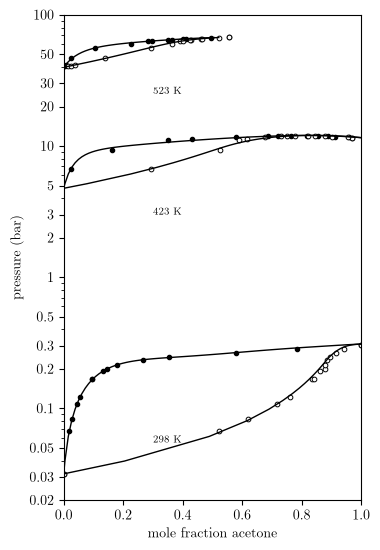

In [5]:
import warnings
from matplotlib.ticker import FixedLocator, NullFormatter, FuncFormatter

# The grid keeps the exact pure ends, because that is where the curves have to meet the
# pure vapor pressures and the driver has an explicit pure-component path for them. The
# interior points stay well clear of 0 and 1: the driver treats a composition within
# 1e-6 of pure AS pure, so a grid built with 1e-6 endpoints lands exactly on that
# tolerance and the ends drop out as unconverged. That is what the first version of this
# cell did, and it is what put Figure 10.3-13's nonconvergence line at x = 1.
GRID = np.concatenate([[0.0], np.linspace(0.004, 0.996, 88), [1.0]])

def isotherm_curves(model_of_T):
    """{T: (x, y, P_bar)} for a model that may differ from isotherm to isotherm."""
    out = {}
    for T in TEMPS:
        # At a pure end UNIQUAC's combinatorial term takes the logarithm of a zero mole
        # fraction. G^ex is nonetheless exactly zero there, because the singular term is
        # multiplied by x_i = 0, and the mixing rule uses only G^ex -- so the value is
        # right and only the warning is spurious. Silenced here, not in the package.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            x, y, P = pxy(model_of_T(T), T, x1=GRID)
        out[T] = (x, y, P / 1e5)
    return out

# Decade labels are unreadable on an axis that has to hold 0.03 bar and 68 bar at once:
# the whole 298 K isotherm would sit between two of them. The printed art labels the
# significant minor ticks instead, and so does this.
TICKS = [0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5, 10, 20, 30, 50, 100]

def draw(curves, dotted=None, ax=None, label_x=(0.30, 0.30, 0.30)):
    """The acetone/water figure: data as markers, model as lines, log pressure."""
    if ax is None:
        _, ax = plt.subplots(figsize=(3.9, 5.6))
    for T in TEMPS:
        P, x, y = DATA[T].T
        ax.plot(x, P, "o", color="k", ms=3.0, lw=0)                      # liquid, filled
        ax.plot(y, P, "o", mfc="white", mec="k", mew=0.7, ms=3.4, lw=0)  # vapor, open
    for T, (x, y, P) in curves.items():
        ax.plot(x, P, "-", color="k", lw=1.0)
        ax.plot(y, P, "-", color="k", lw=1.0)
    if dotted:
        # Figure 10.3-13's caption calls the k12 = 0 curves DOTTED, so they are dotted.
        # A round-capped (1, 1.5) pattern reads as dots but keeps enough ink per unit
        # length to survive offset printing at figure scale, which a true 0.5 pt dot
        # does not.
        for T, (x, y, P) in dotted.items():
            ax.plot(x, P, color="k", lw=0.8, ls=(0, (1, 1.5)), dash_capstyle="round")
            ax.plot(y, P, color="k", lw=0.8, ls=(0, (1, 1.5)), dash_capstyle="round")
    ax.set_yscale("log")
    ax.set_xlim(0, 1); ax.set_ylim(0.02, 100)
    ax.yaxis.set_major_locator(FixedLocator(TICKS))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(FuncFormatter(
        lambda v, _: f"{v:g}" if v >= 1 else f"{v:.2f}".rstrip("0")))
    ax.set_xlabel("mole fraction acetone")
    ax.set_ylabel("pressure (bar)")
    for T, xl, yl in zip(TEMPS, label_x, (0.055, 3.0, 25.0)):
        ax.text(xl, yl, f"{T:.0f} K", fontsize=7)
    return ax

fig9 = plt.figure(figsize=(3.9, 5.6))
ax9 = fig9.add_subplot(111)
CURVES_9 = isotherm_curves(lambda T: ws_nrtl(*PER_ISOTHERM[T]))
draw(CURVES_9, ax=ax9)
fig9.tight_layout()

## Strategy 2 — fit once, predict everywhere else (Figure 10.3-10)

The parameters of an equation-of-state + $G^{ex}$ model are, as the chapter puts it,
"essentially independent of temperature." If that is true, the three constants fitted to the
**298 K** isotherm alone should carry to 423 K and 523 K — 125 and 225 degrees away — with no
further fitting.

This is a real test with a real answer, so it is run below rather than asserted.

  parameters fitted at 298 K only: tau12 = +2.6752, tau21 = -0.6322, k12 = +0.4817

    298.15 K (fitted   ):  mean |dP| =  1.08 %   mean |dy| = 0.0097   (13 points)
    423.15 K (PREDICTED):  mean |dP| =  6.99 %   mean |dy| = 0.0324   (14 points)
    523.15 K (PREDICTED):  mean |dP| = 11.14 %   mean |dy| = 0.0769   (14 points)


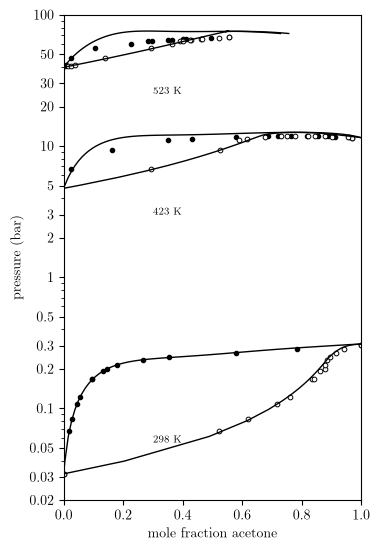

In [6]:
AT_298 = PER_ISOTHERM[298.15]
m298 = ws_nrtl(*AT_298)
print(f"  parameters fitted at 298 K only: tau12 = {AT_298[0]:+.4f}, "
      f"tau21 = {AT_298[1]:+.4f}, k12 = {AT_298[2]:+.4f}\n")
for T in TEMPS:
    dP, dy, n = deviations(m298, T)
    role = "fitted" if T == 298.15 else "PREDICTED"
    print(f"    {T:6.2f} K ({role:9s}):  mean |dP| = {100*dP:5.2f} %   mean |dy| = {dy:.4f}"
          f"   ({n} points)")

fig10 = plt.figure(figsize=(3.9, 5.6))
ax10 = fig10.add_subplot(111)
CURVES_10 = isotherm_curves(lambda T: m298)
draw(CURVES_10, ax=ax10)
fig10.tight_layout()

**The claim holds, with a number attached to it.** One isotherm's parameters carry 225 K with
the pressure error rising from 1 % to about 7 % at 423 K and 11 % at 523 K. That is not a fit,
and for an extrapolation of that size it is remarkable — but it is also the weakest of the four
strategies at high temperature, which is not what a reader would guess. Strategies 3 and 4 do
better, and the reason follows.

## Strategy 3 — reuse activity-coefficient parameters (Figure 10.3-11)

The property that makes the Sec. 9.9 mixing rule useful in practice: **parameters obtained by
the ordinary low-pressure $\gamma$-$\phi$ data reduction of Sec. 10.2 can be dropped straight
into it.** That is what the enormous DECHEMA compilations of activity-coefficient parameters
become — an input to high-pressure equation-of-state calculations, at no extra cost.

The chapter uses DECHEMA's reported NRTL parameters for 298 K. Those are a licensed
compilation, so this notebook does the same reduction the compilers did, on the 298 K data
already here: $\gamma_i = y_i P / x_i P_i^{vap}$ at a total pressure of a third of an
atmosphere, where the vapor is ideal to well within the scatter, then NRTL fitted to those
activity coefficients. **The parameters are ours, and the route is DECHEMA's.**

Only $k_{12}$ is then left, and it is set the way the chapter says: adjust it until the $G^{ex}$
the equation-of-state model predicts matches the activity coefficient model's $G^{ex}$ near the
middle of the composition range.

  gamma-phi reduction of the 298 K data:  tau12 = 0.8891, tau21 = 1.2737
    gamma at infinite dilution: acetone 6.86,  water 5.50
    Gex(x = 0.5) = 1082.2 J/mol
    k12 that reproduces that Gex from the equation of state: 0.17658

    298.15 K (correlated):  mean |dP| =  5.77 %   mean |dy| = 0.0194
    423.15 K (PREDICTED ):  mean |dP| =  2.16 %   mean |dy| = 0.0164
    523.15 K (PREDICTED ):  mean |dP| =  3.10 %   mean |dy| = 0.0246


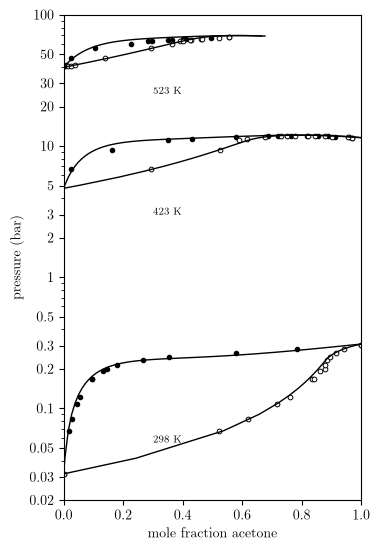

In [7]:
T0 = 298.15
d = DATA[T0][(DATA[T0][:, 1] > 0) & (DATA[T0][:, 1] < 1)]
P_d, x_d, y_d = d.T
Psat0 = np.array([psat[s].P(T0) / 1e5 for s in SPECIES])
gam1 = y_d * P_d / (x_d * Psat0[0])                     # Eq. 10.2-1, ideal vapor
gam2 = (1 - y_d) * P_d / ((1 - x_d) * Psat0[1])

def nrtl_resid(p):
    m = NRTL(p[0], p[1], alpha=ALPHA)
    G = np.array([m.gamma([a, 1 - a], T0) for a in x_d])
    return np.concatenate([np.log(G[:, 0] / gam1), np.log(G[:, 1] / gam2)])

GP = tuple(optimize.least_squares(nrtl_resid, [1.0, 1.0]).x)
nrtl_gp = NRTL(*GP, alpha=ALPHA)
GEX_TARGET = nrtl_gp.gex([0.5, 0.5], T0)
print(f"  gamma-phi reduction of the 298 K data:  tau12 = {GP[0]:.4f}, tau21 = {GP[1]:.4f}")
print(f"    gamma at infinite dilution: acetone {nrtl_gp.gamma([1e-9, 1], T0)[0]:.2f},"
      f"  water {nrtl_gp.gamma([1, 1e-9], T0)[1]:.2f}")
print(f"    Gex(x = 0.5) = {GEX_TARGET:.1f} J/mol")

def gex_from_eos(model, x, T, P):
    """Gex from the equation of state: RT sum x_i ln[phi_i(mixture)/phi_i(pure)].

    The pure-fluid fugacity coefficient is taken from the pure PengRobinson object
    rather than from the mixture model at a unit composition. Those are the same
    number, but the second route asks an activity coefficient model to evaluate
    itself at x_i = 0, and UNIQUAC's combinatorial term contains a logarithm that is
    singular there. Ask the pure fluid a pure-fluid question.
    """
    x = np.asarray(x, dtype=float)
    ln_mix = np.log(model.phi(x, T, P, "liquid"))
    ln_pure = np.array([c.ln_phi(T, P, phase="liquid") for c in model.components])
    return float(R * T * (x @ (ln_mix - ln_pure)))

P_REF = 1.013e5                                  # a compressed liquid for both at 298 K
build3 = lambda k12: WongSandler(pure(), nrtl_gp, kij=np.array([[0.0, k12], [k12, 0.0]]))
K12_3 = optimize.brentq(lambda k: gex_from_eos(build3(float(k)), [0.5, 0.5], T0, P_REF)
                                  - GEX_TARGET, -0.6, 0.8, xtol=1e-10)
m3 = build3(K12_3)
print(f"    k12 that reproduces that Gex from the equation of state: {K12_3:.5f}\n")
for T in TEMPS:
    dP, dy, n = deviations(m3, T)
    role = "correlated" if T == T0 else "PREDICTED"
    print(f"    {T:6.2f} K ({role:10s}):  mean |dP| = {100*dP:5.2f} %   mean |dy| = {dy:.4f}")

fig11 = plt.figure(figsize=(3.9, 5.6))
ax11 = fig11.add_subplot(111)
CURVES_11 = isotherm_curves(lambda T: m3)
draw(CURVES_11, ax=ax11)
fig11.tight_layout()

**Nothing here was fitted to a pressure.** The NRTL
parameters came from a low-pressure activity-coefficient reduction, and $k_{12}$ came from
matching an excess Gibbs energy — and the model predicts the 423 K and 523 K isotherms **better
than the parameters fitted directly to 298 K bubble pressures did in Figure 10.3-10.**

The reason is that the direct fit of Strategy 2 is free to gain a small improvement at 298 K by
moving into a corner of parameter space that has no physical content — its $\tau_{21}$ comes
out negative. The $\gamma$-$\phi$ parameters are constrained by the activity coefficients
themselves, so they stay where the thermodynamics is, and they travel better. **A better fit at
one temperature is not the same as a better model.**

## Strategy 4 — no data at all (Figure 10.3-12)

The last strategy uses no measurement of this mixture whatsoever. The recipe of the chapter,
step by step:

1. Run **UNIFAC** at 25 $^\circ$C — group contributions only, acetone as CH$_3$CO + CH$_3$ and
   water as H$_2$O — to get the two infinite-dilution activity coefficients and $G^{ex}$ at
   $x_1 = 0.5$.
2. Adjust the two **UNIQUAC** parameters to reproduce those infinite-dilution coefficients.
   UNIQUAC is algebraically equivalent to UNIFAC but written in molecules rather than groups,
   which is what the mixing rule wants.
3. Adjust $k_{12}$ to reproduce the $G^{ex}$ from step 1.

Then predict every isotherm. The molecular size and surface parameters $r$ and $q$ are the
UNIFAC group sums, so even those are not fitted.

  UNIFAC at 25 C:  gamma1_inf = 8.0511   gamma2_inf = 7.0854   Gex(0.5) = 1115.8 J/mol
    UNIQUAC r = [2.3373, 1.7334],  q = [2.7308, 2.4561]
    UNIQUAC tau12 = 0.63483, tau21 = 0.72800   (reproduces gamma_inf to 6.0e-10)
    k12 = 0.11130

    298.15 K (PREDICTED):  mean |dP| =  4.29 %   mean |dy| = 0.0149


    423.15 K (PREDICTED):  mean |dP| =  2.84 %   mean |dy| = 0.0199
    523.15 K (PREDICTED):  mean |dP| =  2.58 %   mean |dy| = 0.0232


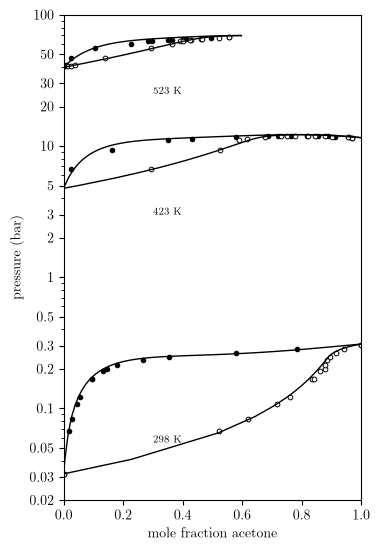

In [8]:
from thermo.data import load_unifac_subgroups
GROUPS = [{18: 1, 1: 1}, {16: 1}]                 # acetone = CH3CO + CH3;  water = H2O
uf = GexFromUNIFAC(UNIFAC(), GROUPS)

EPS = 1e-9
g1_inf = uf.gamma([EPS, 1 - EPS], T0)[0]
g2_inf = uf.gamma([1 - EPS, EPS], T0)[1]
GEX_UF = uf.gex([0.5, 0.5], T0)
print(f"  UNIFAC at 25 C:  gamma1_inf = {g1_inf:.4f}   gamma2_inf = {g2_inf:.4f}"
      f"   Gex(0.5) = {GEX_UF:.1f} J/mol")

sub = load_unifac_subgroups().set_index("subgroup_no")
r_uq = [float(sum(n * sub.loc[k, "R"] for k, n in g.items())) for g in GROUPS]
q_uq = [float(sum(n * sub.loc[k, "Q"] for k, n in g.items())) for g in GROUPS]
print(f"    UNIQUAC r = {[round(v, 4) for v in r_uq]},  q = {[round(v, 4) for v in q_uq]}")

def uq_resid(p):
    m = UNIQUAC(r_uq, q_uq, tau12=np.exp(p[0]), tau21=np.exp(p[1]))
    return [np.log(m.gamma([EPS, 1 - EPS], T0)[0] / g1_inf),
            np.log(m.gamma([1 - EPS, EPS], T0)[1] / g2_inf)]

TAU_UQ = tuple(np.exp(optimize.least_squares(uq_resid, [0.0, 0.0]).x))
uq = UNIQUAC(r_uq, q_uq, tau12=TAU_UQ[0], tau21=TAU_UQ[1])
print(f"    UNIQUAC tau12 = {TAU_UQ[0]:.5f}, tau21 = {TAU_UQ[1]:.5f}"
      f"   (reproduces gamma_inf to {abs(uq.gamma([EPS,1-EPS],T0)[0]/g1_inf-1):.1e})")

build4 = lambda k12: WongSandler(pure(), uq, kij=np.array([[0.0, k12], [k12, 0.0]]))
K12_4 = optimize.brentq(lambda k: gex_from_eos(build4(float(k)), [0.5, 0.5], T0, P_REF)
                                  - GEX_UF, -0.6, 0.9, xtol=1e-10)
m4 = build4(K12_4)
print(f"    k12 = {K12_4:.5f}\n")
for T in TEMPS:
    dP, dy, n = deviations(m4, T)
    print(f"    {T:6.2f} K (PREDICTED):  mean |dP| = {100*dP:5.2f} %   mean |dy| = {dy:.4f}")

fig12 = plt.figure(figsize=(3.9, 5.6))
ax12 = fig12.add_subplot(111)
CURVES_12 = isotherm_curves(lambda T: m4)
draw(CURVES_12, ax=ax12)
fig12.tight_layout()

**No measurement of acetone/water was used to draw that figure.** Group contributions at one
temperature, two algebraic conversions, and the equation of state carries it from 0.03 bar to
68 bar and across 225 K.

The chapter's caution is the right one to keep: this does not make UNIFAC more accurate, it
extends UNIFAC's range. If the group-contribution prediction were poor for this pair, the
figure would be poor too — the mixing rule has no way to know.

## Figure 10.3-13 — what the mixing rule contributed

The comparison that justifies the previous four figures. Same equation of state, same pure
fluids, same solver, same data — but the **van der Waals one-fluid mixing rule** of Eqs. 9.4-8
and 9.4-9, whose single parameter $k_{12}$ is fitted to the 298 K isotherm, with the higher
temperatures predicted.

The dotted curves set $k_{12} = 0$, which is emphatically **not** the ideal-solution case.

In [9]:
def vdw(k12):
    return PRMixture(pure(), kij=np.array([[0.0, k12], [k12, 0.0]]))

def vdw_resid(p):
    m, r = vdw(float(p[0])), []
    for P_exp, x1, y1 in DATA[T0]:
        if x1 <= 0.0 or x1 >= 1.0:
            continue
        P, _ = m.bubble_pressure([x1, 1 - x1], T0, P_guess=P_exp * 1e5)
        r.append(np.log(P / 1e5 / P_exp) if np.isfinite(P) else 3.0)
    return r

K12_VDW = float(optimize.least_squares(vdw_resid, [-0.25], diff_step=1e-3,
                                       bounds=([-0.9], [0.9])).x[0])
mv = vdw(K12_VDW)
print(f"  van der Waals one-fluid, k12 fitted to the 298 K isotherm: k12 = {K12_VDW:.4f}")
for T in TEMPS:
    dP, dy, n = deviations(mv, T)
    role = "fitted" if T == T0 else "predicted"
    print(f"    {T:6.2f} K ({role:9s}):  mean |dP| = {100*dP:6.2f} %   mean |dy| = {dy:.4f}")

CURVES_13 = isotherm_curves(lambda T: mv)
DOTTED_13 = isotherm_curves(lambda T: vdw(0.0))
print("\n  with k12 = 0, the equation of state has no bubble point at all at low acetone:")
for T in TEMPS:
    x, y, P = DOTTED_13[T]
    bad = x[~np.isfinite(P)]
    edge = f"x_acetone < {bad.max():.3f}" if bad.size else "none"
    print(f"    {T:6.2f} K:  {int(np.sum(~np.isfinite(P))):2d}/{len(x)} points fail,  {edge}")

  van der Waals one-fluid, k12 fitted to the 298 K isotherm: k12 = -0.2633
    298.15 K (fitted   ):  mean |dP| =  25.67 %   mean |dy| = 0.0669
    423.15 K (predicted):  mean |dP| =  16.24 %   mean |dy| = 0.0689


    523.15 K (predicted):  mean |dP| =  20.72 %   mean |dy| = 0.0484



  with k12 = 0, the equation of state has no bubble point at all at low acetone:
    298.15 K:  12/90 points fail,  x_acetone < 0.129
    423.15 K:  13/90 points fail,  x_acetone < 0.141
    523.15 K:  61/90 points fail,  x_acetone < 1.000


  isotherms with both species subcritical: [298.15, 423.15]
  nonconvergence boundary drawn at x_acetone = 0.141   (the chapter says 'less than about 0.15')


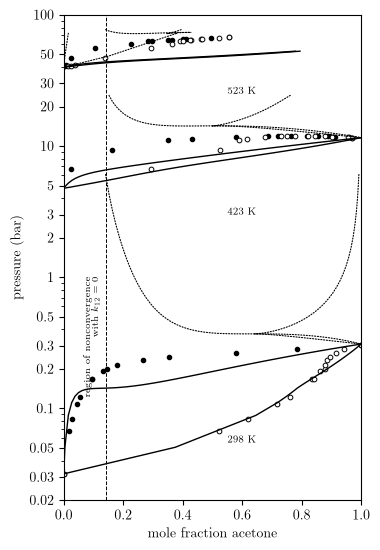

In [10]:
fig13 = plt.figure(figsize=(3.9, 5.6))
ax13 = fig13.add_subplot(111)
draw(CURVES_13, dotted=DOTTED_13, ax=ax13, label_x=(0.55, 0.55, 0.55))

# The nonconvergence boundary the printed figure marks, placed where it actually falls.
# Only the isotherms on which BOTH species are subcritical can contribute: at 523 K
# acetone is above its critical temperature, so the acetone-rich half of that isotherm
# has no bubble point for a reason that has nothing to do with k12, and including it
# would put this line at x = 1 -- which is what the first version of this cell did.
T_SUBCRIT = [T for T in TEMPS if T < min(c.Tc for c in pure())]
edge = max(x[~np.isfinite(P)].max() for T, (x, y, P) in DOTTED_13.items()
           if T in T_SUBCRIT and np.any(~np.isfinite(P)))
ax13.axvline(edge, color="k", ls="--", lw=0.7)
ax13.text(edge - 0.02, 0.35, "region of nonconvergence\nwith $k_{12} = 0$",
          fontsize=6.5, rotation=90, ha="right", va="center")
fig13.tight_layout()
print(f"  isotherms with both species subcritical: {T_SUBCRIT}")
print(f"  nonconvergence boundary drawn at x_acetone = {edge:.3f}"
      f"   (the chapter says 'less than about 0.15')")

**Two things the comparison shows, and one it does not.**

The van der Waals one-fluid rule is not merely less accurate here, it is inadequate: even the
*correlation* at 298 K, with its one constant fitted to those very points, is off by roughly
25 % in pressure, against about 1 % for the Wong-Sandler rule in Figure 10.3-9. The predictions
at higher temperature are no better. One binary constant cannot represent a mixture this far
from ideality, and that is the whole reason Sec. 9.9 exists.

With $k_{12} = 0$ the model predicts behavior so extreme that the bubble-point calculation has
no solution at all below roughly $x_{\rm acetone} = 0.14$ — the residual $\sum K_i x_i - 1$
never reaches zero at any pressure there. The chapter reports the same failure, "for acetone
mole fractions less than about 0.15", from a different program. **Setting a binary parameter to
zero is not the same as assuming an ideal solution.**

What the comparison does *not* reproduce is the false liquid-liquid phase split the text
describes for the fitted curve at 298 K — a local maximum in pressure at low acetone. Our
least-squares $k_{12}$ gives a curve that rises monotonically. The feature is real and very
close by: it appears for $k_{12}$ above about $-0.24$, roughly $0.02$ from the optimum, and it
grows quickly. See the sensitivity check below rather than taking either statement on trust.

In [11]:
# How close the false liquid-liquid split is to the fitted value. A local maximum in the
# bubble pressure at low acetone is the phase split the chapter describes; it is not present
# at the least-squares optimum, and it is not far away either.
print("    k12      mean |dP| %   bubble curve below x = 0.5")
for k in (-0.28, -0.27, K12_VDW, -0.25, -0.24, -0.23, -0.22, -0.20):
    m = vdw(k)
    e = [abs(m.bubble_pressure([a, 1 - a], T0, P_guess=p * 1e5)[0] / 1e5 / p - 1)
         for p, a, _ in DATA[T0] if 0 < a < 1]
    x, y, P = pxy(m, T0, n=200)
    ok = np.isfinite(P); xs, Ps = x[ok], P[ok] / 1e5
    lo = xs < 0.5
    i = int(np.argmax(Ps[lo]))
    split = 0 < i < int(lo.sum()) - 1 and Ps[lo][i] > Ps[lo][-1] * 1.001
    shape = (f"local maximum at x = {xs[lo][i]:.3f}, {Ps[lo][i]:.3f} bar, "
             f"falling to {Ps[lo][-1]:.3f}") if split else "rises monotonically"
    mark = "  <- fitted" if abs(k - K12_VDW) < 1e-6 else ""
    print(f"  {k:+.4f}    {100*np.nanmean(e):8.2f}    {shape}{mark}")

    k12      mean |dP| %   bubble curve below x = 0.5


  -0.2800       26.41    rises monotonically


  -0.2700       23.76    rises monotonically


  -0.2633       25.67    rises monotonically  <- fitted


  -0.2500       33.96    rises monotonically


  -0.2400       48.24    local maximum at x = 0.055, 0.218 bar, falling to 0.201


  -0.2300       70.49    local maximum at x = 0.045, 0.274 bar, falling to 0.205


  -0.2200      101.99    local maximum at x = 0.040, 0.352 bar, falling to 0.210


  -0.2000      202.42    local maximum at x = 0.030, 0.606 bar, falling to 0.220


## What the four strategies cost and what they give

In [12]:
rows = [("10.3-9",  "NRTL fitted per isotherm",            9, lambda T: ws_nrtl(*PER_ISOTHERM[T])),
        ("10.3-10", "NRTL fitted at 298 K only",           3, lambda T: m298),
        ("10.3-11", "NRTL from gamma-phi + Gex match",     0, lambda T: m3),
        ("10.3-12", "UNIFAC -> UNIQUAC, fully predictive", 0, lambda T: m4),
        ("10.3-13", "van der Waals one-fluid",             1, lambda T: mv)]
print(f"  {'figure':9s} {'model':36s} {'fitted':>6s}   mean |dP| %, by isotherm")
print(f"  {'':9s} {'':36s} {'consts':>6s}   {'298 K':>7s} {'423 K':>7s} {'523 K':>7s}")
for tag, name, nfit, mk in rows:
    errs = [100 * deviations(mk(T), T)[0] for T in TEMPS]
    print(f"  {tag:9s} {name:36s} {nfit:6d}   " + " ".join(f"{e:7.2f}" for e in errs))
print("\n  'fitted' counts constants adjusted against acetone/water VLE data;")
print("  the PRSV kappa1 of each pure fluid is not one of them.")

  figure    model                                fitted   mean |dP| %, by isotherm
                                                 consts     298 K   423 K   523 K


  10.3-9    NRTL fitted per isotherm                  9      1.08    1.20    0.35


  10.3-10   NRTL fitted at 298 K only                 3      1.08    6.99   11.14


  10.3-11   NRTL from gamma-phi + Gex match           0      5.77    2.16    3.10
  10.3-12   UNIFAC -> UNIQUAC, fully predictive       0      4.29    2.84    2.58


  10.3-13   van der Waals one-fluid                   1     25.67   16.24   20.72

  'fitted' counts constants adjusted against acetone/water VLE data;
  the PRSV kappa1 of each pure fluid is not one of them.


## Print art

In [13]:
# --- Print art: Figures 10.3-9 through 10.3-13 -----------------------------
#   pdf/Fig_10.3-N.pdf -> deliverables/figures/print-bw/ch10/c10f0NN.pdf
# The slugs restart per section in the .docx; the verified map in
# revision_notes/pre-submission/chapters/c10.md section 1 is what production needs:
#   10.3-9 -> c10f032   10.3-10 -> c10f033   10.3-11 -> c10f034
#   10.3-12 -> c10f035  10.3-13 -> c10f036
# Filled markers are measured liquid, open markers measured vapor; all pure black.
import os
os.makedirs("pdf", exist_ok=True)
for tag, f in (("10.3-9", fig9), ("10.3-10", fig10), ("10.3-11", fig11),
               ("10.3-12", fig12), ("10.3-13", fig13)):
    path = f"pdf/Fig_{tag}.pdf"
    f.savefig(path, dpi=300, bbox_inches="tight")
    print("wrote", path)

wrote pdf/Fig_10.3-9.pdf
wrote pdf/Fig_10.3-10.pdf


wrote pdf/Fig_10.3-11.pdf


wrote pdf/Fig_10.3-12.pdf


wrote pdf/Fig_10.3-13.pdf


## Your turn

1. Strategy 3 beat Strategy 2 at high temperature. Refit Strategy 2 starting from the
   $\gamma$-$\phi$ parameters instead of the default start. Does the optimizer stay near them,
   and if it moves away, how much does it gain at 298 K and lose at 523 K?
2. The NRTL non-randomness parameter is fixed at $\alpha = 0.35$ throughout, on the chapter's
   instruction. Treat it as a fourth adjustable constant in Strategy 1. How much does the fit
   improve, and does the improvement justify a parameter?
3. Fit $\kappa_1$ for water over 273-373 K only, and again over the full subcritical range.
   The value barely moves. Now do the same for acetone, where it does move. What does that
   difference say about which pure fluid the PRSV correction is really for?
4. Strategy 4 used UNIFAC at 25 $^\circ$C. Run it at 60 $^\circ$C instead and repeat the two
   conversions. How much do the UNIQUAC parameters and $k_{12}$ change, and does the prediction
   at 523 K get better or worse?
5. The 523 K isotherm has no pure-acetone end because acetone is supercritical there. Find the
   composition at which the computed 523 K envelope actually closes, and compare it with the
   highest acetone mole fraction Griswold and Wong were able to measure.